In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pymc as pm
import pytensor.tensor as pt
import pytensor


[*********************100%***********************]  1 of 1 completed
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


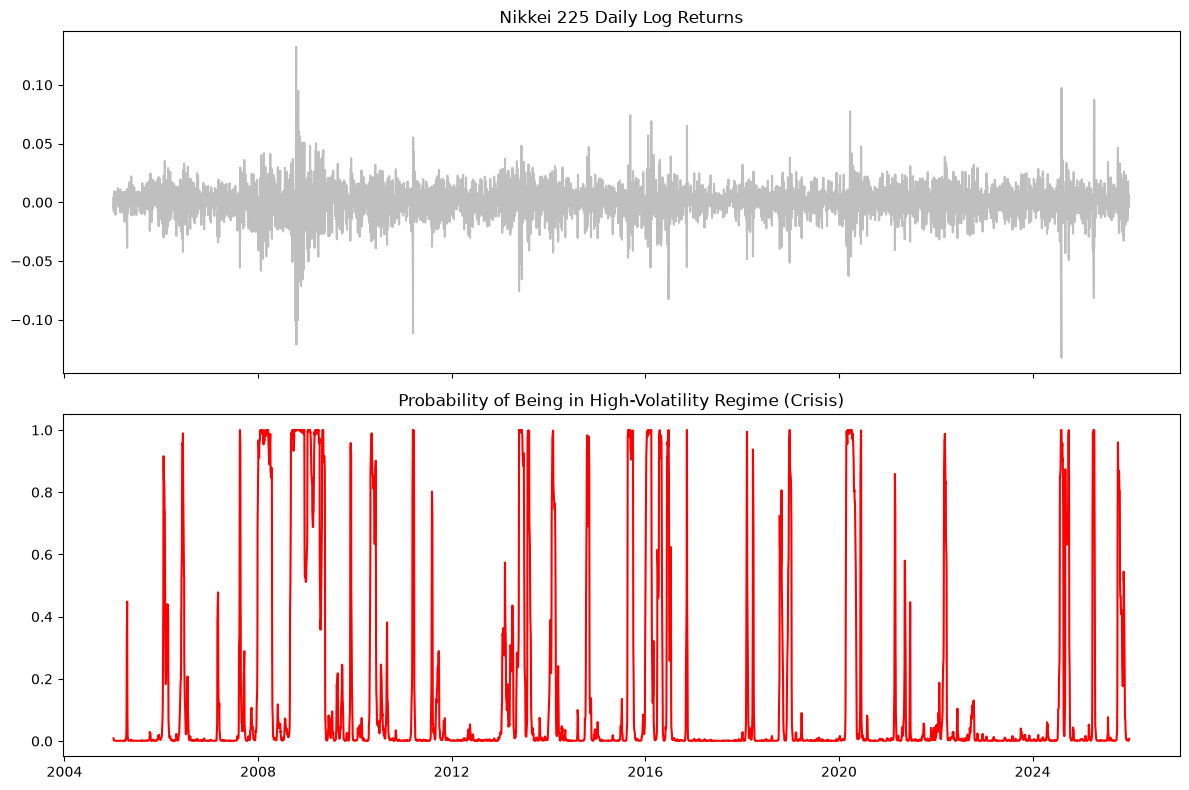

                        Markov Switching Model Results                        
Dep. Variable:                 Return   No. Observations:                 5137
Model:               MarkovRegression   Log Likelihood               15156.616
Date:                Mon, 06 Jul 2026   AIC                         -30301.232
Time:                        10:09:23   BIC                         -30261.966
Sample:                             0   HQIC                        -30287.489
                               - 5137                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      4.557      0.000       0.000       0.001
sigma2         0.0001    3.6e-06     31.193      0.0

In [4]:
#実際のデータから統計モデル（頻度主義的統計）での予測を行う
data = yf.download("^N225", start="2005-01-01", end="2025-12-31",group_by="columns")
data["Return"] = np.log(data[("^N225", "Close")] / data[("^N225", "Close")].shift(1))
data = data.dropna()

model = sm.tsa.MarkovRegression(data["Return"], k_regimes=2, trend="c", switching_variance=True)
results = model.fit()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(data.index, data["Return"], color='gray', alpha=0.5)
axes[0].set_title('Nikkei 225 Daily Log Returns')

axes[1].plot(data.index, results.smoothed_marginal_probabilities[1], color="red")
axes[1].set_title('Probability of Being in High-Volatility Regime (Crisis)')

plt.tight_layout()
plt.show()

print(results.summary())

In [17]:
#強い事前分布を仮定（実装のデバックと）
X = np.array(data["Return"])
N = len(X)

with pm.Model() as msm_bayes:
    p00 = pm.Beta('p00', alpha=98, beta=2)
    p11 = pm.Beta('p11', alpha=93, beta=7)

    P = pt.stack([
        pt.stack([p00, 1-p00]),
        pt.stack([1-p11, p11])
    ])
    # 先ほどの結果（平時σ²=0.0001 → σ=0.01, 危機σ²=0.0008 → σ=0.028）を参考に、少し広めの半正規分布を設定
    sigma = pm.HalfNormal('sigma', sigma=[0.01, 0.05], shape=2)
    mu = pm.Normal('mu', mu=[0.0008, -0.0027], sigma=0.01, shape=2)

    def forward_step(x_t, Gamma_prev, P, mu, sigma):

        Gamma_pred = pt.dot(Gamma_prev, P)
    

        log_emission = -0.5 * pt.log(2 * np.pi * sigma ** 2) -0.5 * ((x_t - mu) / sigma) ** 2
        emission = pt.exp(log_emission) + 1e-12
        

        Gamma_next = Gamma_pred * emission
        return Gamma_next / pt.sum(Gamma_next)

    init_prob = pt.constant(np.array([0.5, 0.5]))

    probabilities, _ = pytensor.scan(
        fn=forward_step,
        sequences=X,
        outputs_info=init_prob,
        non_sequences=[P, mu, sigma])
    

    pm.Potential('marginal_likelihood', pt.sum(pt.log(pt.sum(probabilities, axis=1))))

    print("MCMCサンプリングを開始します（これには数分かかる場合があります）...")
    idata = pm.sample(draws=1000, tune=1000, chains=2, target_accept=0.95, random_seed=42)

print("サンプリングが完了しました！")
    
        

        
    

Squeeze{axis=0}.0
Add.0
MCMCサンプリングを開始します（これには数分かかる場合があります）...


/tmp/ipykernel_14827/681318820.py:30: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  probabilities, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [p00, p11, sigma, mu]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 566 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


サンプリングが完了しました！


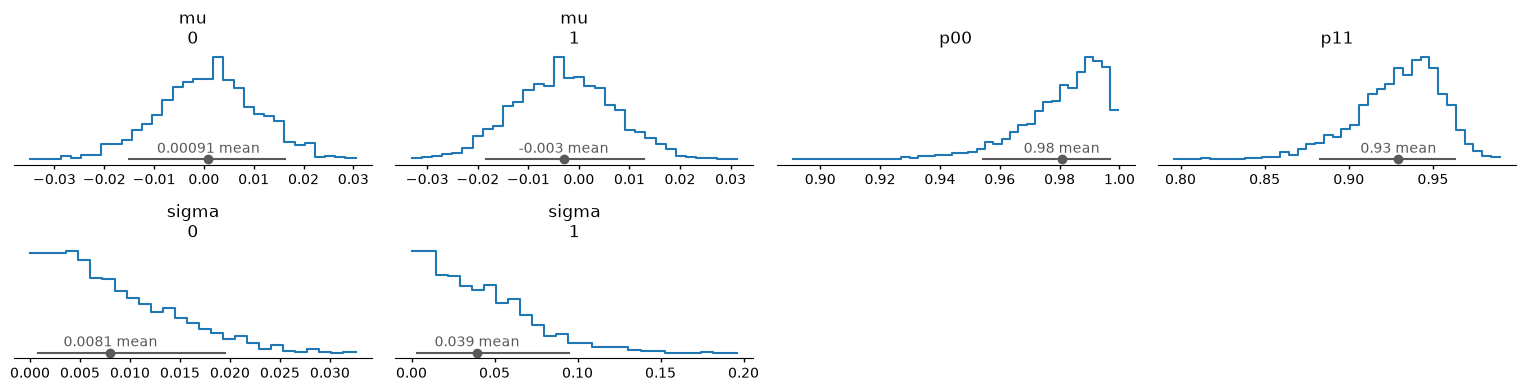

In [38]:
import arviz_plots as azp
import matplotlib.pyplot as plt

# idata（DataTree）の「posterior」部分だけを直接 arviz の関数に放り込みます
azp.plot_dist(idata, kind="hist")

plt.tight_layout()
plt.show()

In [40]:
az.summary(idata, var_names=["mu", "sigma", "p00", "p11"])
#r_hat:1.01以下（chainが同じ事後分布に収束しているか）、ess_bulk:400以上あるか(自己相関を見る)、ess_tail:1.01以下か（信用区間の上限下限が不安定かどうか）
#ほぼ一致するが、事前分布が原因か、尤度が原因かがわからない

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],0.0009,0.0098,-0.015,0.016,1607,1260,1.00,0.00024,0.00017
mu[1],-0.003,0.0097,-0.018,0.013,1726,1181,1.00,0.00023,0.00016
sigma[0],0.0081,0.0061,0.00077,0.02,1181,779,1.00,0.00015,0.00011
sigma[1],0.039,0.03,0.0031,0.095,1095,521,1.00,0.00071,0.00063
p00,0.9807,0.0143,0.95,1,1398,836,1.00,0.00035,0.00039
p11,0.929,0.026,0.88,0.96,1741,1058,1.00,0.00062,0.00054


In [41]:
print(idata.sample_stats.diverging.sum().item())
#ダイヴァージェンスの確認

0


In [45]:
#弱情報事前分布での検証（p00, p11, mu, sigma）
X = np.array(data["Return"])
N = len(X)

with pm.Model() as msm_bayes:
    p00 = pm.Beta('p00', alpha=2, beta=2)  # 平均0.5、弱い情報
    p11 = pm.Beta('p11', alpha=2, beta=2)

    P = pt.stack([
        pt.stack([p00, 1-p00]),
        pt.stack([1-p11, p11])
    ])
    # 先ほどの結果（平時σ²=0.0001 → σ=0.01, 危機σ²=0.0008 → σ=0.028）を参考に、少し広めにとる半正規分布を設定
    mu = pm.Normal('mu', mu=0, sigma=0.05, shape=2)  
    sigma = pm.HalfNormal('sigma', sigma=0.1, shape=2)

    def forward_step(x_t, Gamma_prev, P, mu, sigma):

        Gamma_pred = pt.dot(Gamma_prev, P)
        
        log_emission = -0.5 * pt.log(2 * np.pi * sigma ** 2) -0.5 * ((x_t - mu) / sigma) ** 2
        emission = pt.exp(log_emission) + 1e-12
        

        Gamma_next = Gamma_pred * emission
        return Gamma_next / pt.sum(Gamma_next)

    init_prob = pt.constant(np.array([0.5, 0.5]))

    probabilities, _ = pytensor.scan(
        fn=forward_step,
        sequences=X,
        outputs_info=init_prob,
        non_sequences=[P, mu, sigma])
    

    pm.Potential('marginal_likelihood', pt.sum(pt.log(pt.sum(probabilities, axis=1))))

    print("MCMCサンプリングを開始します（これには数分かかる場合があります）...")
    idata = pm.sample(draws=1000, tune=1000, chains=2, target_accept=0.95, random_seed=42)

print("サンプリングが完了しました！")
    
        

        
    

/tmp/ipykernel_14827/2177217429.py:29: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  probabilities, _ = pytensor.scan(


MCMCサンプリングを開始します（これには数分かかる場合があります）...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [p00, p11, mu, sigma]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 408 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


サンプリングが完了しました！


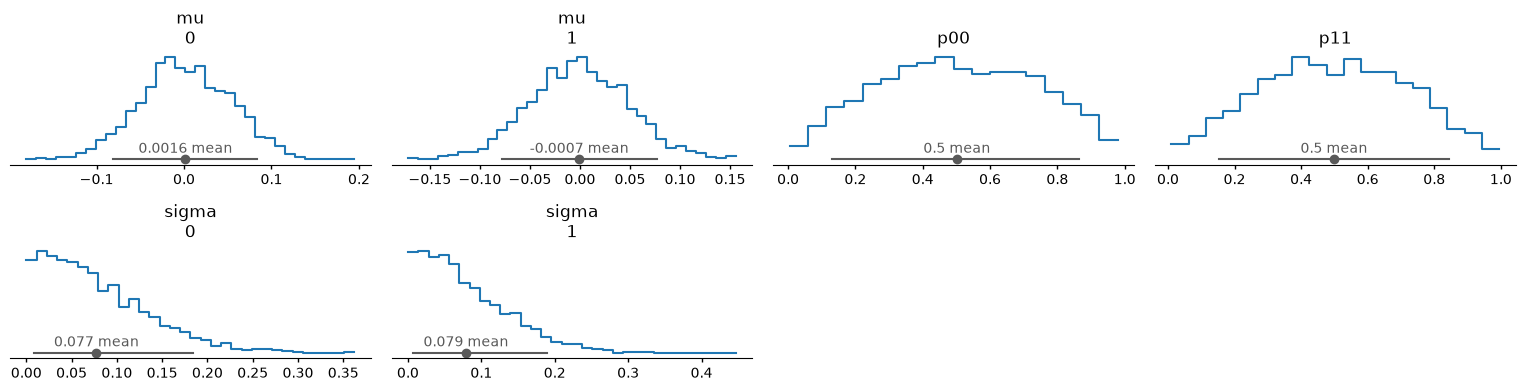

In [46]:
import arviz_plots as azp
import matplotlib.pyplot as plt

# idata（DataTree）の「posterior」部分だけを直接 arviz の関数に放り込みます
azp.plot_dist(idata, kind="hist")

plt.tight_layout()
plt.show()

In [47]:
az.summary(idata, var_names=["mu", "sigma", "p00", "p11"])
#ボラティリティ（sigma）の違いなし、p00がBeta(2,2)の期待値と同じになっており、遷移確率について何も語っていない
#ラベルスイッチングが発生（「状態0」と「状態1」のどっちを平時/危機と呼ぶかのルール（順序制約）を数式に書いてあげなかったため、MCMCが途中で迷子になって名前をひっくり返してしまう）

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],0.002,0.052,-0.081,0.083,1591,1226,1.00,0.0013,0.00089
mu[1],-0.001,0.049,-0.078,0.077,1620,1295,1.00,0.0012,0.00088
sigma[0],0.077,0.058,0.0082,0.18,992,771,1.00,0.0015,0.0013
sigma[1],0.079,0.06,0.0068,0.19,1053,716,1.00,0.0015,0.0013
p00,0.5,0.229,0.13,0.86,2018,1231,1.00,0.005,0.0026
p11,0.499,0.218,0.15,0.84,1918,1523,1.00,0.0049,0.0027


In [48]:
print(idata.sample_stats.diverging.sum().item())


0


In [53]:
#ラベルスイッチングが解消された場合の弱情報事前分布
X = np.array(data["Return"])
N = len(X)

with pm.Model() as msm_bayes:
    p00 = pm.Beta('p00', alpha=2, beta=2)  # 平均0.5、弱い情報
    p11 = pm.Beta('p11', alpha=2, beta=2)

    P = pt.stack([
        pt.stack([p00, 1-p00]),
        pt.stack([1-p11, p11])
    ])
    # 先ほどの結果（平時σ²=0.0001 → σ=0.01, 危機σ²=0.0008 → σ=0.028）を参考に、少し広めの半正規分布を設定
    mu = pm.Normal('mu', mu=0, sigma=0.02, shape=2)
    # sigmaの大小関係を強制することで、ラベルスイッチングを防ぐ
    sigma_raw = pm.HalfNormal('sigma_raw', sigma=0.1, shape=2)
    sigma = pm.Deterministic('sigma', pt.sort(sigma_raw))  # 小さい順に並べ替え（順序制約をつける）

    def forward_step(x_t, Gamma_prev, P, mu, sigma):

        Gamma_pred = pt.dot(Gamma_prev, P)
        
        log_emission = -0.5 * pt.log(2 * np.pi * sigma ** 2) -0.5 * ((x_t - mu) / sigma) ** 2
        emission = pt.exp(log_emission) + 1e-12
        

        Gamma_next = Gamma_pred * emission
        return Gamma_next / pt.sum(Gamma_next)

    init_prob = pt.constant(np.array([0.5, 0.5]))

    probabilities, _ = pytensor.scan(
        fn=forward_step,
        sequences=X,
        outputs_info=init_prob,
        non_sequences=[P, mu, sigma])
    

    pm.Potential('marginal_likelihood', pt.sum(pt.log(pt.sum(probabilities, axis=1))))

    print("MCMCサンプリングを開始します（これには数分かかる場合があります）...")
    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.95, random_seed=42)

print("サンプリングが完了しました！")
    
        

        
    

/tmp/ipykernel_14827/2722751239.py:31: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  probabilities, _ = pytensor.scan(


MCMCサンプリングを開始します（これには数分かかる場合があります）...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p00, p11, mu, sigma_raw]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 676 seconds.


サンプリングが完了しました！


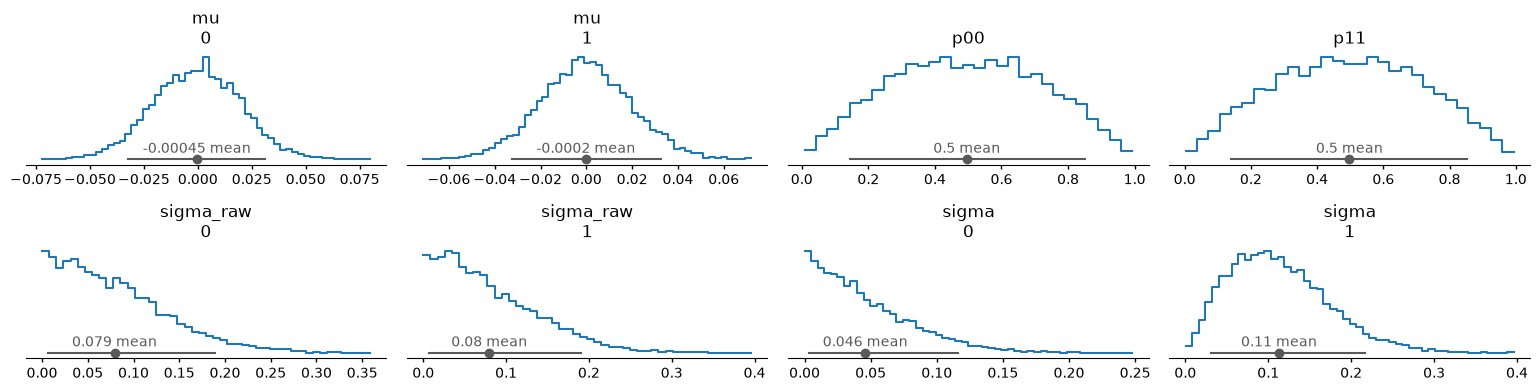

In [54]:
import arviz_plots as azp
import matplotlib.pyplot as plt

# idata（DataTree）の「posterior」部分だけを直接 arviz の関数に放り込みます
azp.plot_dist(idata, kind="hist")

plt.tight_layout()
plt.show()

In [55]:
az.summary(idata, var_names=["mu", "sigma", "p00", "p11"])#r_hat:1.01以下、ess_bulk:400以上あるか
#sigmaを分離できたが、遷移確率は五分五分→「p00=0.98」という強い確信は、事前分布が作り出していたものであって、データそのものが持っていた情報ではなかった

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[0],-0.0005,0.0202,-0.032,0.031,6969,5860,1.00,0.00024,0.00017
mu[1],-0.0002,0.02,-0.032,0.032,6252,5250,1.00,0.00025,0.00018
sigma[0],0.046,0.038,0.0032,0.12,2924,2652,1.00,0.00059,0.00056
sigma[1],0.113,0.0593,0.031,0.22,8244,5273,1.00,0.00063,0.00048
p00,0.496,0.221,0.15,0.85,6816,5173,1.00,0.0027,0.0014
p11,0.497,0.221,0.14,0.85,7495,4879,1.00,0.0025,0.0014


In [56]:
print(idata.sample_stats.diverging.sum().item())

0
